Utilizzo del dispositivo: cpu
Caricamento del modello CLIP (potrebbe richiedere del tempo la prima volta)...
✅ Modello CLIP caricato con successo.

Lettura dei dati dal file CSV: image_analysis_qwen_2x2_with_metadata_max_tokens_512.csv

Anteprima del DataFrame:
                                          Image Name  \
0         aleksey-savrasov_courtyard-spring-1853.jpg   
1                                                      
2                                                      
3                                                      
4                                                      
5  alfred-sisley_village-on-the-banks-of-the-sein...   
6                                                      
7                                                      
8                                                      
9                                                      

                        ArtworkTitle        ArtistName ArtworkYear Period  \
0                 Courtyard. Spring.  alekse

Analisi righe CSV: 100%|██████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 48086.58it/s]



✅ Trovati 100 file immagine (presunti) e 100 descrizioni allineate dopo il filtro.

Elenco completo dei file immagine estratti dal CSV (dopo il filtro e allineamento):
1. 'aleksey-savrasov_courtyard-spring-1853.jpg'
2. 'alfred-sisley_village-on-the-banks-of-the-seine-1872.jpg'
3. 'chaldin-alex_lilies.jpg'
4. 'currier-and-ives_catching-a-trout-1854.jpg'
5. 'edvard-munch_girl-yawning-1913.jpg'
6. 'edward-robert-hughes_day.jpg'
7. 'gerard-van-honthorst_diana-with-her-nymphs-1650.jpg'
8. 'giorgio-vasari_assumption-of-the-virgin-detail-1.jpg'
9. 'hans-andersen-brendekilde_en-skovtur-ved-odense-a-1897.jpg'
10. 'helene-de-beauvoir_untitled-9.jpg'
...

✅ Estratti 100 nomi di file immagine e 100 descrizioni totali pulite dal CSV.

Estrazione degli embeddings e calcolo delle similarità:


Elaborazione Coppie: 100%|███████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.49it/s]



✅ Estratti con successo gli embeddings per 100 coppie.
✅ Calcolate 100 similarità immagine-testo.


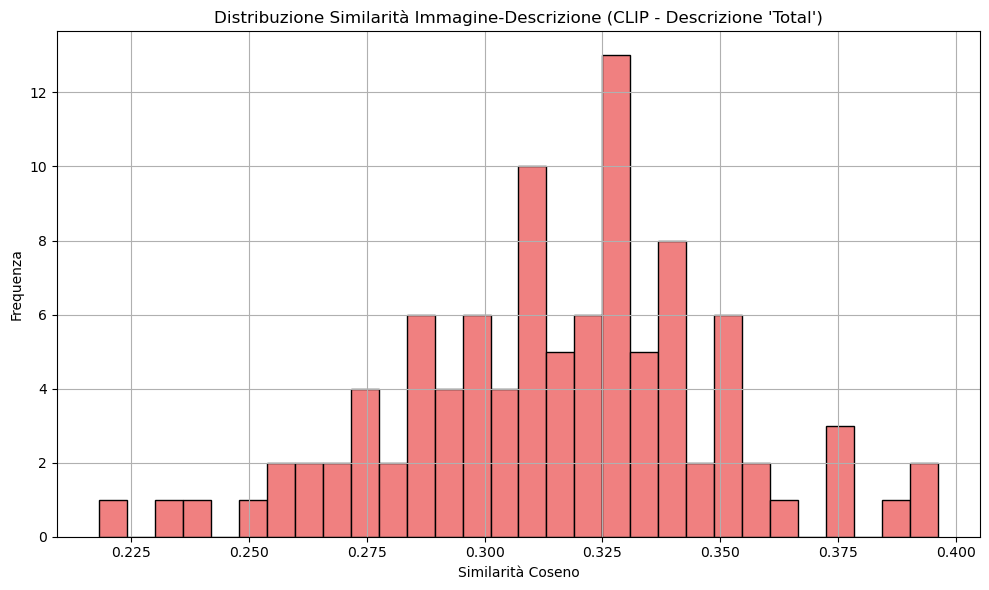


=== Statistiche Complessive Similarità Immagine-Descrizione (CLIP - Descrizione 'Total') ===
Numero di coppie elaborate: 100
Media: 0.3153
Mediana: 0.3163
Deviazione standard: 0.0339
Minima: 0.2183
Massima: 0.3961

✅ Statistiche complessive salvate in 'clip_similarity_statistics_TOTAL.csv'
✅ Similarità individuali salvate in 'clip_individual_similarities_TOTAL.csv'

=== 🔻 Peggiori match Immagine-Descrizione (Descrizione 'Total') ===
File: nicholas-roerich_a-bird-with-spread-wings.jpg, Similarità: 0.2183
Descrizione: 'The artwork titled "A Bird with Spread Wings" by Nicholas Roerich, created around 1905, is a piece of symbolic painting that embodies a rich array of themes and emotions, rooted in the Symbolist movem...'

File: victor-hugo_the-cellist-1856.jpg, Similarità: 0.2350
Descrizione: 'The image you've shared is a section of the artwork titled "The Cellist" created by Victor Hugo in 1856. This piece is part of a broader series of abstract works, which were characterized by a stro

In [9]:
import os
import pandas as pd
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
import traceback
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# --- IMPORT CLIP ---
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# --- Scarica le risorse NLTK (eseguirà solo se le risorse non sono già presenti) ---
try:
    nltk.data.find('corpora/stopwords')
except:
    print("Download NLTK stopwords...")
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except:
    print("Download NLTK punkt tokenizer...")
    nltk.download('punkt')

# --- 1. Configurazione Iniziale ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Utilizzo del dispositivo: {device}")

# Percorsi - Adatta questi percorsi alla tua struttura di directory su Jupyter/Colab
# Basandoci sui percorsi che hai usato nelle versioni precedenti del tuo codice
PATHS = {
    "csv_file": "image_analysis_qwen_2x2_with_metadata_max_tokens_512.csv", # Il tuo CSV con i metadati delle immagini
    "image_files_folder": "images100", # La cartella contenente i file immagine
    "output_statistics_csv": "clip_similarity_statistics_TOTAL.csv", # NOME FILE AGGIORNATO
    "output_individual_similarities_csv": "clip_individual_similarities_TOTAL.csv" # NOME FILE AGGIORNATO
}

# --- 2. Caricamento Modello CLIP ---
try:
    # Carica il modello CLIP pre-addestrato e il processore
    print("Caricamento del modello CLIP (potrebbe richiedere del tempo la prima volta)...")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    print("✅ Modello CLIP caricato con successo.")
except Exception as e:
    print(f"❌ Errore durante il caricamento del modello CLIP: {e}")
    traceback.print_exc(file=sys.stdout)
    sys.exit(1)

def read_image_data_from_csv(csv_path):
    """
    Legge il file CSV e estrae i nomi dei file immagine e le descrizioni totali.
    Si aspetta che i nomi delle immagini non inizino con 'Fragment' e cerca
    la riga con 'Total' nella colonna 'Description Type' (presumendo un offset).
    """
    final_image_filenames = []
    final_descriptions = []
    
    try:
        df = pd.read_csv(csv_path, keep_default_na=False)
        
        print("\nAnteprima del DataFrame:")
        print(df.head(10))

        print("\nColonne disponibili:")
        print(df.columns.tolist())
        
        # Colonna per i nomi delle immagini. Se 'Image Name' non c'è, cerca alternative.
        possible_image_columns = ['Image Name', 'ArtworkTitle', 'ArtistName'] # Aggiunte per robustezza
        image_col = None
        for col in possible_image_columns:
            if col in df.columns:
                image_col = col
                break
            
        if image_col is None:
            print("❌ Nessuna colonna con i nomi dei file immagine trovata tra le possibili opzioni.")
            return [], []

        # Nomi delle colonne per descrizione e tipo di descrizione
        description_type_col = "Description Type"
        description_col = "Description"

        if description_type_col not in df.columns or description_col not in df.columns:
             print(f"❌ Il CSV non contiene le colonne essenziali '{description_type_col}' e '{description_col}'.")
             return [], []

        print("\nInizio la ricerca di nomi file immagine e descrizioni allineate...")
        # L'offset di 4 righe sembra essere una caratteristica del tuo CSV specifico.
        # Se la struttura del tuo CSV dovesse cambiare, questo offset andrebbe modificato.
        for idx in tqdm(df.index, desc="Analisi righe CSV"):
            current_filename_raw = str(df.loc[idx, image_col]).strip().replace('"', '')
            
            if not current_filename_raw or current_filename_raw.lower() == 'nan' or \
               current_filename_raw.lower().startswith('fragment'):
                continue

            image_name_base = current_filename_raw

            # Calcola l'indice della riga della descrizione 'Total'
            # Qui si assume che la riga 'Total' sia sempre 4 righe dopo l'ingresso dell'immagine principale.
            # Questo è un pattern specifico del tuo CSV.
            description_row_idx = idx + 4 

            if description_row_idx >= len(df):
                continue

            description_type_candidate = str(df.loc[description_row_idx, description_type_col]).strip()

            if description_type_candidate.lower() == 'total':
                actual_description = str(df.loc[description_row_idx, description_col]).strip()
                
                if actual_description:
                    final_image_filenames.append(image_name_base)
                    final_descriptions.append(actual_description)

        print(f"\n✅ Trovati {len(final_image_filenames)} file immagine (presunti) e {len(final_descriptions)} descrizioni allineate dopo il filtro.")
        
    except Exception as e:
        print(f"❌ Errore nella lettura o nel filtro del CSV: {e}")
        traceback.print_exc(file=sys.stdout)
        return [], []
        
    return final_image_filenames, final_descriptions

# --- Funzione di pulizia del testo ---
def clean_description_text(text):
    """
    Rimuove parole e frasi indesiderate dalla descrizione, normalizza e rimuove stop words.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()

    phrases_to_remove = [] # Lasciato vuoto come nel tuo ultimo codice
    phrases_to_remove.sort(key=len, reverse=True)

    for phrase in phrases_to_remove:
        text = text.replace(phrase, " ")

    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ''.join([i for i in text if not i.isdigit()])

    # Importante: se le descrizioni sono generate in inglese, usa 'english' per le stopwords
    # Il tuo CSV indica "image_analysis_qwen_2x2_with_metadata_max_tokens_512.csv"
    # e Qwen genera in inglese, quindi è probabile che le descrizioni siano in inglese.
    words = word_tokenize(text, language='english') # CAMBIATO a 'english' per Qwen
    stop_words_english = set(stopwords.words('english')) # CAMBIATO a 'english'
    filtered_words = [word for word in words if word.strip() and word not in stop_words_english]
    
    text = " ".join(filtered_words)
    text = " ".join(text.split()).strip()
    
    if text:
        text = text[0].upper() + text[1:]

    return text

# --- 4. Caricamento Dati dal CSV ---
print(f"\nLettura dei dati dal file CSV: {PATHS['csv_file']}")
# Ho cambiato il nome della funzione da read_song_data_from_csv a read_image_data_from_csv
image_filenames, total_descriptions = read_image_data_from_csv(PATHS["csv_file"])

if not image_filenames:
    print("❌ Errore: Nessun nome di file immagine valido e nessuna descrizione totale estratta dal CSV dopo il filtro.")
    sys.exit(1)

print("\nElenco completo dei file immagine estratti dal CSV (dopo il filtro e allineamento):")
for i, filename in enumerate(image_filenames):
    if i < 10:
        print(f"{i+1}. '{filename}'")
    elif i == 10:
        print("...")

descriptions_cleaned = [clean_description_text(desc) for desc in total_descriptions]

print(f"\n✅ Estratti {len(image_filenames)} nomi di file immagine e {len(descriptions_cleaned)} descrizioni totali pulite dal CSV.")

# --- 5. Estrazione Embeddings Immagine e Testo per ogni coppia ---
image_embeddings_list = []
text_embeddings_list = []
processed_pairs_info = [] # Conterrà filename e descrizione originale per l'output

print("\nEstrazione degli embeddings e calcolo delle similarità:")
for i in tqdm(range(len(image_filenames)), desc="Elaborazione Coppie"):
    filename = image_filenames[i] # Questo è il nome base dell'immagine dal CSV
    description_for_embedding = descriptions_cleaned[i]
    description_original = total_descriptions[i] # Mantieni la descrizione originale

    # print(f"\nProcessing file: '{filename}'") # Commentato per ridurre l'output
    
    MAX_TEXT_CHAR_LENGTH = 512 # Limite di caratteri per la descrizione per l'embedding
    
    if isinstance(description_for_embedding, str) and len(description_for_embedding) > MAX_TEXT_CHAR_LENGTH:
        truncated_description = description_for_embedding[:MAX_TEXT_CHAR_LENGTH]
        if not truncated_description.endswith('...'):
            truncated_description += "..."
    else:
        truncated_description = description_for_embedding

    if not filename or str(filename).strip().lower() == 'nan':
        # print(f"❌ Saltato: Nome file non valido '{filename}'")
        continue

    # --- CLIP Specifico: Trova il file immagine sul disco ---
    full_image_path = None
    base_name, _ = os.path.splitext(filename) # Rimuovi qualsiasi estensione se presente nel CSV
    extensions_to_try = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'] # Estensioni comuni
    
    found_image = False
    for ext in extensions_to_try:
        attempt_path = os.path.join(PATHS["image_files_folder"], base_name + ext)
        if os.path.isfile(attempt_path):
            full_image_path = attempt_path
            found_image = True
            # print(f"✅ Trovata immagine: '{full_image_path}'") # Commentato per ridurre l'output
            break
            
    if not found_image:
        print(f"❌ Impossibile trovare un file immagine per '{filename}' con estensioni comuni nel percorso specificato.")
        continue
    
    if not truncated_description.strip():
        # print(f"⚠️ Saltato '{filename}': La descrizione è diventata vuota dopo la pulizia.")
        continue

    try:
        # --- CLIP Specifico: Ottieni l'embedding dell'immagine ---
        # print(f"Elaborazione immagine: '{full_image_path}'") # Commentato
        image = Image.open(full_image_path).convert("RGB")
        inputs = clip_processor(images=image, return_tensors="pt").to(device)
        image_features = clip_model.get_image_features(pixel_values=inputs.pixel_values)
        
        # Ottieni l'embedding del testo
        # print(f"Elaborazione testo: '{truncated_description[:50]}...'") # Commentato
        inputs = clip_processor(text=[truncated_description], return_tensors="pt", padding=True, truncation=True).to(device)
        text_features = clip_model.get_text_features(input_ids=inputs.input_ids)

        image_embeddings_list.append(image_features.cpu().detach()) # Sposta sulla CPU
        text_embeddings_list.append(text_features.cpu().detach())   # Sposta sulla CPU
        processed_pairs_info.append({
            'filename': os.path.basename(full_image_path),
            'description': description_original # Salva la descrizione originale
        })
        # print(f"✅ '{filename}' elaborato con successo") # Commentato

    except Exception as e:
        print(f"❌ ERRORE durante l'elaborazione di '{filename}': {str(e)}")
        traceback.print_exc(file=sys.stdout)
        continue

if not image_embeddings_list:
    print("\n❌ Errore: Nessuna coppia immagine-testo è stata elaborata con successo.")
    sys.exit(1)

# Concatenazione degli embeddings (assicurati che siano tutti dello stesso formato e dimensione)
image_embeddings_tensor = torch.vstack(image_embeddings_list)
text_embeddings_tensor = torch.vstack(text_embeddings_list)

print(f"\n✅ Estratti con successo gli embeddings per {len(image_embeddings_tensor)} coppie.")

# --- 6. Calcolo Similarità Coseno ---
image_embeddings_norm = torch.nn.functional.normalize(image_embeddings_tensor, p=2, dim=-1)
text_embeddings_norm = torch.nn.functional.normalize(text_embeddings_tensor, p=2, dim=-1)

similarities = (image_embeddings_norm * text_embeddings_norm).sum(dim=-1)
similarities_np = similarities.cpu().detach().numpy()

print(f"✅ Calcolate {len(similarities_np)} similarità immagine-testo.")

# --- 7. Visualizzazione Distribuzione Similarità ---
plt.figure(figsize=(10, 6))
plt.hist(similarities_np, bins=30, color='lightcoral', edgecolor='black')
plt.title("Distribuzione Similarità Immagine-Descrizione (CLIP - Descrizione 'Total')") # Titolo aggiornato
plt.xlabel("Similarità Coseno")
plt.ylabel("Frequenza")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 8. Statistiche Complessive ---
print("\n=== Statistiche Complessive Similarità Immagine-Descrizione (CLIP - Descrizione 'Total') ===") # Titolo aggiornato
num_pairs = len(similarities_np)
mean_sim = np.mean(similarities_np)
median_sim = np.median(similarities_np)
std_sim = np.std(similarities_np)
min_sim = np.min(similarities_np)
max_sim = np.max(similarities_np)

print(f"Numero di coppie elaborate: {num_pairs}")
print(f"Media: {mean_sim:.4f}")
print(f"Mediana: {median_sim:.4f}")
print(f"Deviazione standard: {std_sim:.4f}")
print(f"Minima: {min_sim:.4f}")
print(f"Massima: {max_sim:.4f}")

# --- 9. Salvataggio Statistiche Complessive su CSV ---
try:
    stats_df = pd.DataFrame({
        'Metrica': ['Numero di Coppie', 'Media', 'Mediana', 'Deviazione Standard', 'Minima', 'Massima'],
        'Valore': [num_pairs, mean_sim, median_sim, std_sim, min_sim, max_sim]
    })
    stats_df.to_csv(PATHS["output_statistics_csv"], index=False)
    print(f"\n✅ Statistiche complessive salvate in '{PATHS['output_statistics_csv']}'")
except Exception as e:
    print(f"❌ Errore durante il salvataggio delle statistiche: {e}")
    traceback.print_exc(file=sys.stdout)

# --- 10. Salvataggio Similarità Individuali ---
if processed_pairs_info:
    individual_similarities_data = []
    for idx, pair_info in enumerate(processed_pairs_info):
        individual_similarities_data.append({
            'Filename Immagine': pair_info['filename'],
            'Descrizione Originale (Total)': pair_info['description'], # Etichetta aggiornata
            'Similarita Coseno': similarities_np[idx]
        })
    
    try:
        individual_sim_df = pd.DataFrame(individual_similarities_data)
        individual_sim_df.to_csv(PATHS["output_individual_similarities_csv"], index=False)
        print(f"✅ Similarità individuali salvate in '{PATHS['output_individual_similarities_csv']}'")
    except Exception as e:
        print(f"❌ Errore durante il salvataggio delle similarità individuali: {e}")
        traceback.print_exc(file=sys.stdout)
else:
    print("\n⚠️ Nessuna coppia immagine-testo elaborata.")

# --- 11. Visualizza Esempi Migliori e Peggiori ---
def print_similarity_examples(indices, title, data_info, similarities_scores, num_examples=5):
    print(f"\n=== {title} ===")
    for i, idx in enumerate(indices):
        if i >= num_examples:
            break
        filename = data_info[idx]['filename']
        description = data_info[idx]['description']
        sim_score = similarities_scores[idx]
        print(f"File: {filename}, Similarità: {sim_score:.4f}")
        print(f"Descrizione: '{description[:200]}...'\n")

# Ordina gli indici per similarità
sorted_indices = np.argsort(similarities_np)

# Visualizza i 5 peggiori match
print_similarity_examples(sorted_indices[:5], "🔻 Peggiori match Immagine-Descrizione (Descrizione 'Total')", processed_pairs_info, similarities_np) # Titolo aggiornato

# Visualizza i 5 migliori match
print_similarity_examples(sorted_indices[-5:][::-1], "🔺 Migliori match Immagine-Descrizione (Descrizione 'Total')", processed_pairs_info, similarities_np) # Titolo aggiornato

print("\nProcesso di analisi CLIP (Descrizione 'Total') completato.")

Utilizzo del dispositivo: cpu
Caricamento del modello CLIP (potrebbe richiedere del tempo la prima volta)...
✅ Modello CLIP caricato con successo.

Lettura dei dati dal file CSV: image_analysis_qwen_2x2_with_metadata_max_tokens_512.csv

Anteprima del DataFrame (per debug):
                                          Image Name  \
0         aleksey-savrasov_courtyard-spring-1853.jpg   
1                                                      
2                                                      
3                                                      
4                                                      
5  alfred-sisley_village-on-the-banks-of-the-sein...   
6                                                      
7                                                      
8                                                      
9                                                      

                        ArtworkTitle        ArtistName ArtworkYear Period  \
0                 Courtyard. Spr

Scansione righe CSV (Somma Fragment): 100%|███████████████████████████████████████| 500/500 [00:00<00:00, 18939.50it/s]


✅ Trovati 100 file immagine e 100 descrizioni combinate dai frammenti dopo il filtro.

--- Prime 5 coppie finali restituite da read_image_data_from_csv_fragment_sum ---
File [0]: 'aleksey-savrasov_courtyard-spring-1853.jpg'
Descrizione [0]: 'The image depicts a portion of the artwork "Courtyard. Spring" by Aleksey Savrasov, painted in 1853....'
File [1]: 'alfred-sisley_village-on-the-banks-of-the-seine-1872.jpg'
Descrizione [1]: 'The image provided is a fragment from the painting "Village on the Banks of the Seine" by Alfred Sis...'
File [2]: 'chaldin-alex_lilies.jpg'
Descrizione [2]: 'The portion of the image you've provided showcases a vibrant and dynamic painting, a section of the ...'
File [3]: 'currier-and-ives_catching-a-trout-1854.jpg'
Descrizione [3]: 'The image provided is a fragment of a larger painting, specifically a portion of "Catching a Trout,"...'
File [4]: 'edvard-munch_girl-yawning-1913.jpg'
Descrizione [4]: 'This image is a fragment of the painting "Girl Yawning" cr


✅ Estratti 100 nomi di file immagine e 100 descrizioni combinate pulite dal CSV.

Estrazione degli embeddings e calcolo delle similarità:


Elaborazione Coppie Immagine-Testo (Somma Fragment): 100%|███████████████████████████| 100/100 [00:09<00:00, 10.71it/s]



✅ Estratti con successo gli embeddings per 100 coppie.
✅ Calcolate 100 similarità immagine-testo.


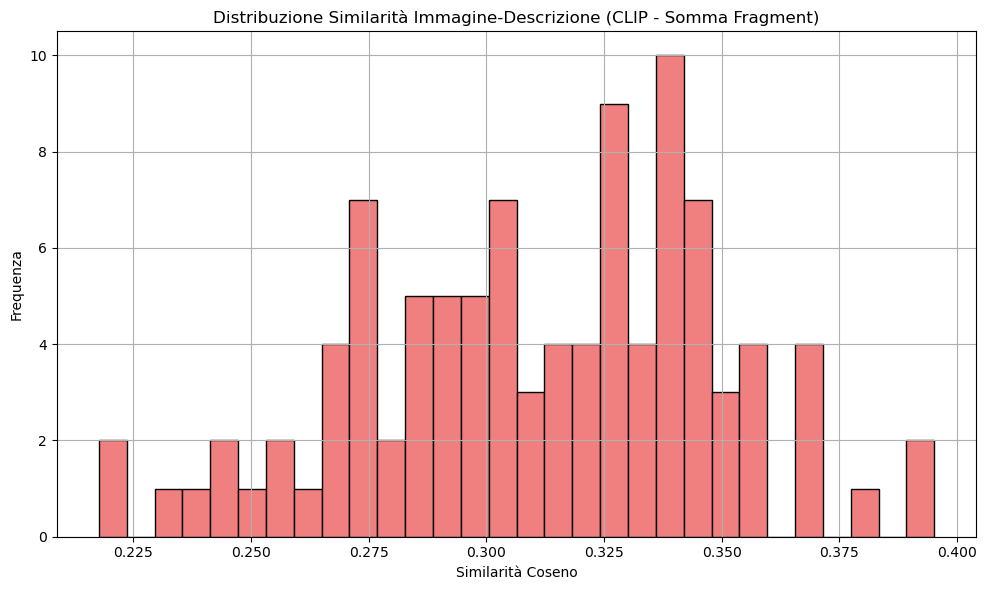


=== Statistiche Complessive Similarità Immagine-Descrizione (CLIP - Somma Fragment) ===
Numero di coppie elaborate: 100
Media: 0.3114
Mediana: 0.3144
Deviazione standard: 0.0372
Minima: 0.2177
Massima: 0.3952

✅ Statistiche complessive salvate in 'clip_similarity_statistics_fragment_sum.csv'
✅ Similarità individuali salvate in 'clip_individual_similarities_fragment_sum.csv'

=== 🔻 Peggiori match Immagine-Descrizione (Somma Fragment) ===
File: pierre-tal-coat_self-portrait.jpg, Similarità: 0.2177
Descrizione (Combinata Frammenti): 'The image provided is a section of an artwork titled "Self-Portrait" by Pierre-Tal-Coat. This particular fragment showcases a stylized, abstract representation of a face, characteristic of the express...'

File: nicholas-roerich_a-bird-with-spread-wings.jpg, Similarità: 0.2195
Descrizione (Combinata Frammenti): 'The image provided shows a close-up portion of a symbolic painting titled "A Bird with Spread Wings," created around 1905 by the artist Nicholas Roe

In [10]:
import os
import pandas as pd
import torch
import numpy as np
import sys
import matplotlib.pyplot as plt
from tqdm import tqdm
import traceback
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# --- IMPORT CLIP ---
from PIL import Image
from transformers import CLIPProcessor, CLIPModel

# --- Scarica le risorse NLTK (eseguirà solo se le risorse non sono già presenti) ---
# Se stai eseguendo questi script per la prima volta o in un nuovo ambiente,
# decommente le righe seguenti per scaricare i dati necessari.
try:
    nltk.data.find('corpora/stopwords')
except:
    print("Download NLTK stopwords...")
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except:
    print("Download NLTK punkt tokenizer...")
    nltk.download('punkt')

# --- 1. Configurazione Iniziale ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Utilizzo del dispositivo: {device}")

# Percorsi - ADATTA QUESTI PERCORSI AL TUO AMBIENTE KAGGLE/JUPYTER
PATHS = {
    "csv_file": "image_analysis_qwen_2x2_with_metadata_max_tokens_512.csv", # Il tuo CSV
    "image_files_folder": "./images100", # La cartella delle tue immagini
    "output_statistics_csv": "clip_similarity_statistics_fragment_sum.csv", # NOME FILE DISTINTO
    "output_individual_similarities_csv": "clip_individual_similarities_fragment_sum.csv" # NOME FILE DISTINTO
}

# Impostazioni aggiuntive per la logica dei frammenti nel CSV
GRID_ROWS = 2
GRID_COLS = 2
TOTAL_GRID_SEGMENTS = GRID_ROWS * GRID_COLS # Dovrebbe essere 4 per 2x2

# --- 2. Caricamento Modello CLIP ---
try:
    print("Caricamento del modello CLIP (potrebbe richiedere del tempo la prima volta)...")
    clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
    clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
    print("✅ Modello CLIP caricato con successo.")
except Exception as e:
    print(f"❌ Errore durante il caricamento del modello CLIP: {e}")
    traceback.print_exc(file=sys.stdout)
    sys.exit(1)

# --- FUNZIONE CORRETTA PER LEGGERE I DATI DELLE IMMAGINI CON "SOMMA FRAGMENT" ---
def read_image_data_from_csv_fragment_sum(csv_path):
    """
    Legge il file CSV, identifica i nomi dei file immagine e costruisce una singola descrizione
    concatenando i testi dei "Fragment 1", "Fragment 2", ecc.
    Gestisce i campi vuoti in 'Image Name' per i frammenti, raggruppando i frammenti sotto l'immagine principale.
    """
    final_image_filenames = []
    final_descriptions = []
    
    try:
        df = pd.read_csv(csv_path, keep_default_na=False)
        
        print("\nAnteprima del DataFrame (per debug):")
        print(df.head(10))

        print("\nColonne disponibili (per debug):")
        print(df.columns.tolist())
        
        image_col = "Image Name" 
        description_type_col = "Description Type"
        description_col = "Description"

        if image_col not in df.columns or description_type_col not in df.columns or description_col not in df.columns:
             print(f"❌ Il CSV non contiene le colonne essenziali '{image_col}', '{description_type_col}', '{description_col}'.")
             return [], []

        print("\nInizio la raccolta delle descrizioni dai frammenti per le immagini...")
        
        current_image_name = None
        current_fragments = [] # Lista per tenere i frammenti del blocco corrente

        for idx, row in tqdm(df.iterrows(), total=len(df), desc="Scansione righe CSV (Somma Fragment)"):
            row_image_name = str(row[image_col]).strip()
            row_description_type = str(row[description_type_col]).strip().lower()
            row_description = str(row[description_col]).strip()

            # Caso 1: Trovato un nome di immagine (inizio di un nuovo blocco)
            if row_image_name and row_image_name.lower() != 'nan' and \
               not row_image_name.lower().startswith('fragment') and \
               not row_image_name.lower().startswith('total'):
                
                # Se abbiamo raccolto frammenti per un'immagine precedente, salvala ora
                if current_image_name and current_fragments:
                    final_image_filenames.append(current_image_name)
                    final_descriptions.append(" ".join(current_fragments).strip())
                
                # Resetta per la nuova immagine
                current_image_name = row_image_name
                current_fragments = [] # Inizia una nuova lista di frammenti
            
            # Caso 2: Trovato un frammento (appartiene all'immagine corrente se `current_image_name` è settato)
            elif current_image_name and row_description_type.startswith('fragment '):
                try:
                    fragment_num = int(row_description_type.split(' ')[1])
                    if 1 <= fragment_num <= TOTAL_GRID_SEGMENTS:
                        if row_description:
                            current_fragments.append(row_description)
                except ValueError:
                    pass # Non è un "Fragment X" valido, ignoralo

            # La riga "Total" non è usata per la descrizione in questo script,
            # ma la sua presenza segnala la fine di un blocco di frammenti.
            # L'aggiunta alla lista finale avviene quando si incontra il prossimo
            # nome immagine o alla fine del file.
            
        # Aggiungi l'ultima immagine dopo che il ciclo è terminato
        if current_image_name and current_fragments:
            final_image_filenames.append(current_image_name)
            final_descriptions.append(" ".join(current_fragments).strip())

        print(f"\n✅ Trovati {len(final_image_filenames)} file immagine e {len(final_descriptions)} descrizioni combinate dai frammenti dopo il filtro.")
        
        print("\n--- Prime 5 coppie finali restituite da read_image_data_from_csv_fragment_sum ---")
        for j in range(min(5, len(final_image_filenames))):
            print(f"File [{j}]: '{final_image_filenames[j]}'")
            print(f"Descrizione [{j}]: '{final_descriptions[j][:100]}...'") # Stampa i primi 100 caratteri
        print(f"Totale coppie processate: {len(final_image_filenames)}")
        print("--------------------------------------------------")

    except Exception as e:
        print(f"❌ Errore nella lettura o nel filtro del CSV: {e}")
        traceback.print_exc(file=sys.stdout)
        return [], []
        
    return final_image_filenames, final_descriptions

# --- Funzione di pulizia del testo (ADATTATA PER INGLESE, BASATA SULL'OUTPUT DI QWEN) ---
def clean_description_text(text):
    """
    Rimuove parole e frasi indesiderate dalla descrizione, normalizza e rimuove stop words.
    """
    if not isinstance(text, str):
        return ""

    text = text.lower()
    phrases_to_remove = [
        "this image depicts",
        "the image shows",
        "a visual representation of",
        "the painting illustrates",
        "the artwork portrays",
        "this image presents"
    ]
    phrases_to_remove.sort(key=len, reverse=True)

    for phrase in phrases_to_remove:
        text = text.replace(phrase, " ")

    text = text.translate(str.maketrans('', '', string.punctuation))
    text = ''.join([i for i in text if not i.isdigit()])

    # Utilizza 'english' per il tokenizer e le stopwords, dato che Qwen genera testo in inglese.
    words = word_tokenize(text, language='english')
    stop_words_list = set(stopwords.words('english'))
    
    filtered_words = [word for word in words if word.strip() and word not in stop_words_list]
    
    text = " ".join(filtered_words)
    text = " ".join(text.split()).strip()
    
    if text:
        text = text[0].upper() + text[1:]
    else:
        text = ""

    return text

# --- 4. Caricamento Dati dal CSV ---
print(f"\nLettura dei dati dal file CSV: {PATHS['csv_file']}")
image_filenames, total_descriptions = read_image_data_from_csv_fragment_sum(PATHS["csv_file"])

if not image_filenames:
    print("❌ Errore: Nessun nome di file immagine valido e nessuna descrizione combinata estratta dal CSV dopo il filtro.")
    sys.exit(1)

print("\nElenco completo dei file immagine estratti dal CSV (dopo la combinazione dei frammenti):")
for i, filename in enumerate(image_filenames):
    if i < 10: # Limita la stampa per non riempire la console
        print(f"{i+1}. '{filename}'")
    elif i == 10:
        print("...")

descriptions_cleaned = [clean_description_text(desc) for desc in total_descriptions]

print(f"\n✅ Estratti {len(image_filenames)} nomi di file immagine e {len(descriptions_cleaned)} descrizioni combinate pulite dal CSV.")

# --- 5. Estrazione Embeddings Immagine e Testo per ogni coppia ---
image_embeddings_list = []
text_embeddings_list = []
processed_pairs_info = []

print("\nEstrazione degli embeddings e calcolo delle similarità:")
# Utilizza enumerate con tqdm per un contatore visivo
for i, filename_base in tqdm(enumerate(image_filenames), total=len(image_filenames), desc="Elaborazione Coppie Immagine-Testo (Somma Fragment)"):
    description_for_embedding = descriptions_cleaned[i]
    description_original = total_descriptions[i]
    
    MAX_TEXT_CHAR_LENGTH = 512
    if isinstance(description_for_embedding, str) and len(description_for_embedding) > MAX_TEXT_CHAR_LENGTH:
        truncated_description = description_for_embedding[:MAX_TEXT_CHAR_LENGTH]
        # Assicurati che la troncazione non tagli a metà una parola se possibile e aggiungi "..."
        if not truncated_description.endswith(('.', '!', '?')) and len(description_for_embedding) > MAX_TEXT_CHAR_LENGTH:
            truncated_description += "..."
    else:
        truncated_description = description_for_embedding

    if not filename_base or str(filename_base).strip().lower() == 'nan':
        continue

    full_image_path = None
    base_name, _ = os.path.splitext(filename_base)
    extensions_to_try = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp']
    
    found_image = False
    for ext in extensions_to_try:
        attempt_path = os.path.join(PATHS["image_files_folder"], base_name + ext)
        if os.path.isfile(attempt_path):
            full_image_path = attempt_path
            found_image = True
            break
            
    if not found_image:
        # print(f"❌ Impossibile trovare un file immagine per '{filename_base}' in '{PATHS['image_files_folder']}'. Saltando.")
        continue # Salta questa coppia se l'immagine non è trovata
    
    if not truncated_description.strip():
        # print(f"❌ Descrizione vuota o solo spazi per '{filename_base}'. Saltando.")
        continue # Salta se la descrizione pulita è vuota

    try:
        image = Image.open(full_image_path).convert("RGB")
        inputs = clip_processor(images=image, return_tensors="pt").to(device)
        image_features = clip_model.get_image_features(pixel_values=inputs.pixel_values)
        
        inputs = clip_processor(text=[truncated_description], return_tensors="pt", padding=True, truncation=True).to(device)
        text_features = clip_model.get_text_features(input_ids=inputs.input_ids)

        image_embeddings_list.append(image_features.cpu().detach())
        text_embeddings_list.append(text_features.cpu().detach())
        processed_pairs_info.append({
            'filename': os.path.basename(full_image_path),
            'description': description_original
        })

    except Exception as e:
        print(f"❌ ERRORE durante l'elaborazione di '{filename_base}': {str(e)}")
        # traceback.print_exc(file=sys.stdout) # Rimuovi o commenta per output più pulito
        continue

if not image_embeddings_list:
    print("\n❌ Errore: Nessuna coppia immagine-testo è stata elaborata con successo.")
    sys.exit(1)

# Concatena tutti i tensori in un unico tensore
image_embeddings_tensor = torch.vstack(image_embeddings_list)
text_embeddings_tensor = torch.vstack(text_embeddings_list)

print(f"\n✅ Estratti con successo gli embeddings per {len(image_embeddings_tensor)} coppie.")

# --- 6. Calcolo Similarità Coseno ---
# Normalizzazione degli embeddings
image_embeddings_norm = torch.nn.functional.normalize(image_embeddings_tensor, p=2, dim=-1)
text_embeddings_norm = torch.nn.functional.normalize(text_embeddings_tensor, p=2, dim=-1)

# Calcolo della similarità coseno (prodotto scalare tra vettori normalizzati)
similarities = (image_embeddings_norm * text_embeddings_norm).sum(dim=-1)
similarities_np = similarities.cpu().detach().numpy()

print(f"✅ Calcolate {len(similarities_np)} similarità immagine-testo.")

# --- 7. Visualizzazione Distribuzione Similarità ---
plt.figure(figsize=(10, 6))
plt.hist(similarities_np, bins=30, color='lightcoral', edgecolor='black')
plt.title("Distribuzione Similarità Immagine-Descrizione (CLIP - Somma Fragment)") # Titolo distinto
plt.xlabel("Similarità Coseno")
plt.ylabel("Frequenza")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 8. Statistiche Complessive ---
print("\n=== Statistiche Complessive Similarità Immagine-Descrizione (CLIP - Somma Fragment) ===") # Titolo distinto
num_pairs = len(similarities_np)
mean_sim = np.mean(similarities_np)
median_sim = np.median(similarities_np)
std_sim = np.std(similarities_np)
min_sim = np.min(similarities_np)
max_sim = np.max(similarities_np)

print(f"Numero di coppie elaborate: {num_pairs}")
print(f"Media: {mean_sim:.4f}")
print(f"Mediana: {median_sim:.4f}")
print(f"Deviazione standard: {std_sim:.4f}")
print(f"Minima: {min_sim:.4f}")
print(f"Massima: {max_sim:.4f}")

# --- 9. Salvataggio Statistiche Complessive su CSV ---
try:
    stats_df = pd.DataFrame({
        'Metrica': ['Numero di Coppie', 'Media', 'Mediana', 'Deviazione Standard', 'Minima', 'Massima'],
        'Valore': [num_pairs, mean_sim, median_sim, std_sim, min_sim, max_sim]
    })
    stats_df.to_csv(PATHS["output_statistics_csv"], index=False)
    print(f"\n✅ Statistiche complessive salvate in '{PATHS['output_statistics_csv']}'")
except Exception as e:
    print(f"❌ Errore durante il salvataggio delle statistiche: {e}")
    traceback.print_exc(file=sys.stdout)

# --- 10. Salvataggio Similarità Individuali ---
if processed_pairs_info:
    individual_similarities_data = []
    for idx, pair_info in enumerate(processed_pairs_info):
        individual_similarities_data.append({
            'Filename Immagine': pair_info['filename'],
            'Descrizione Originale (Combinata Frammenti)': pair_info['description'], # Colonna distinta
            'Similarita Coseno': similarities_np[idx]
        })
    
    try:
        individual_sim_df = pd.DataFrame(individual_similarities_data)
        individual_sim_df.to_csv(PATHS["output_individual_similarities_csv"], index=False)
        print(f"✅ Similarità individuali salvate in '{PATHS['output_individual_similarities_csv']}'")
    except Exception as e:
        print(f"❌ Errore durante il salvataggio delle similarità individuali: {e}")
        traceback.print_exc(file=sys.stdout)
else:
    print("\n⚠️ Nessuna coppia immagine-testo elaborata.")

# --- 11. Visualizza Esempi Migliori e Peggiori ---
def print_similarity_examples(indices, title, data_info, similarities_scores, num_examples=5):
    print(f"\n=== {title} ===")
    for i, idx in enumerate(indices):
        if i >= num_examples:
            break
        filename = data_info[idx]['filename']
        description = data_info[idx]['description']
        sim_score = similarities_scores[idx]
        print(f"File: {filename}, Similarità: {sim_score:.4f}")
        print(f"Descrizione (Combinata Frammenti): '{description[:200]}...'\n") # Etichetta distinta

sorted_indices = np.argsort(similarities_np) # Ordina in base alla similarità

print_similarity_examples(sorted_indices[:5], "🔻 Peggiori match Immagine-Descrizione (Somma Fragment)", processed_pairs_info, similarities_np) # Titolo distinto
print_similarity_examples(sorted_indices[-5:][::-1], "🔺 Migliori match Immagine-Descrizione (Somma Fragment)", processed_pairs_info, similarities_np) # Titolo distinto

print("\nProcesso di analisi CLIP (Somma Fragment) completato.")